In [164]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings

warnings.filterwarnings('ignore')

In [165]:
df = pd.read_csv('loan_risk_prediction_dataset.csv')

df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


# EDA

In [166]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [167]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')

In [168]:
df.drop('City', axis=1, inplace=True)

In [169]:
columns = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'EmploymentType', 'LoanApproved']

for cols in columns: 
    null_val = df[cols].isna().value_counts()

df['CreditScore'] = df['CreditScore'].fillna(df['CreditScore'].mean())
df['Income'] = df['Income'].fillna(df['Income'].mean())
df['Education'] = df['Education'].fillna(df['Education'].mode()[0])

In [170]:
df.isna().sum()

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
EmploymentType     0
LoanApproved       0
dtype: int64

In [171]:
df['Education'].value_counts()

Education
Bachelors      1418
PhD            1199
Masters        1198
High School    1185
Name: count, dtype: int64

In [172]:
df['EmploymentType'].value_counts()

EmploymentType
Self-Employed    1730
Unemployed       1660
Salaried         1610
Name: count, dtype: int64

In [173]:
df.shape

(5000, 9)

In [174]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,14802.355799,8046.542413,157.404704,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39990.250000,14455.250000,440.000000,10.000000,0.000000
50%,43.000000,49738.123022,19842.500000,575.494590,20.000000,0.000000
75%,56.000000,59447.000000,25326.750000,706.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


<Axes: >

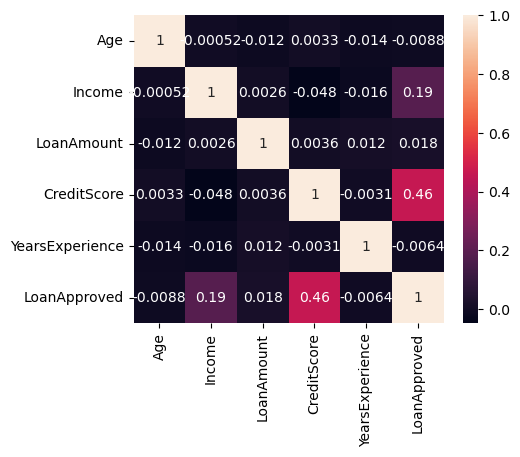

In [175]:
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='EmploymentType', ylabel='count'>

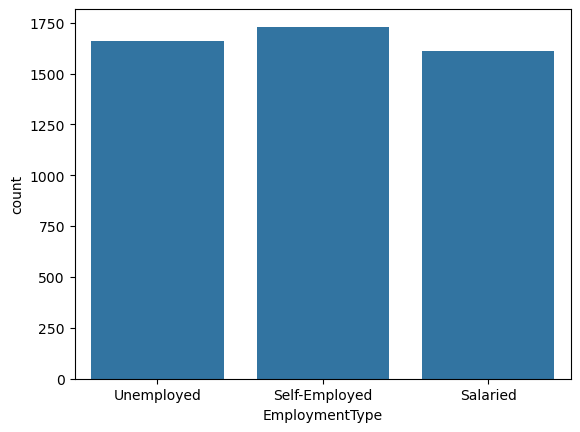

In [176]:
sns.countplot(x='EmploymentType', data=df)

<Axes: xlabel='Education', ylabel='count'>

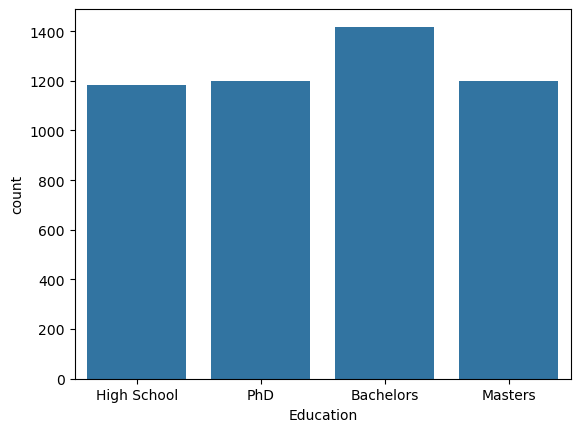

In [177]:
sns.countplot(data=df, x='Education')

<Axes: xlabel='Gender', ylabel='count'>

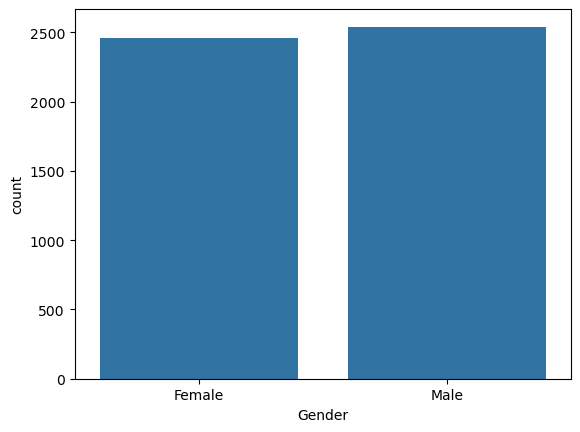

In [178]:
sns.countplot(data=df, x='Gender')

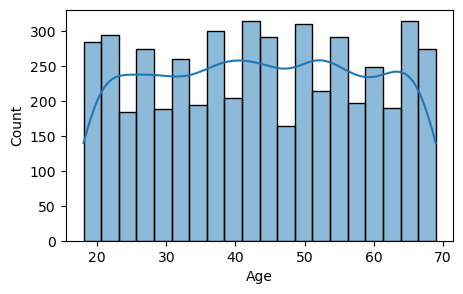

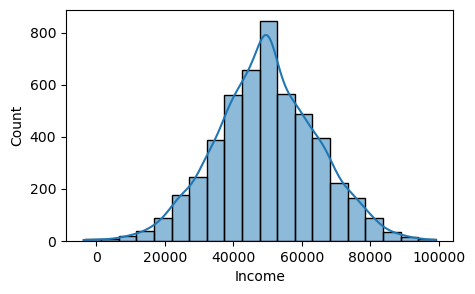

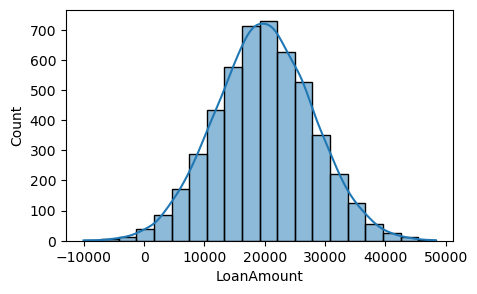

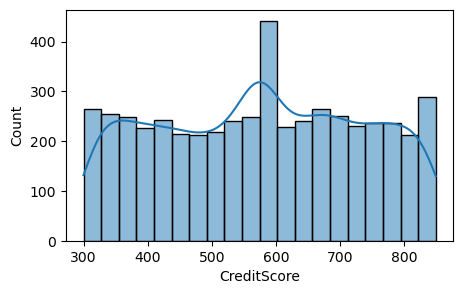

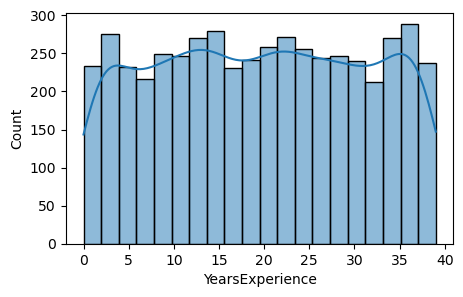

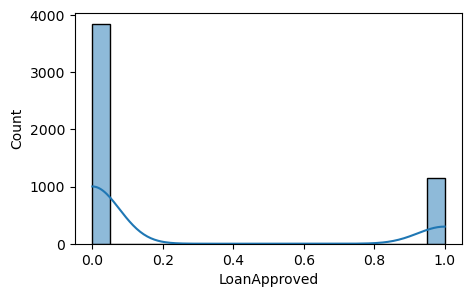

In [179]:
numeric_columns = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'LoanApproved']

for cols in numeric_columns:
    plt.figure(figsize=(5,3))
    sns.histplot(df[cols], kde=True, bins=20) 

In [180]:
df[df['LoanAmount'] <= 0].value_counts().sum()

np.int64(28)

In [181]:
df[df['Income'] <= 0].value_counts().sum()

np.int64(3)

In [182]:
df.loc[df['LoanAmount'] <= 0, 'LoanAmount'] = df['LoanAmount'].median()
df.loc[df['Income'] <= 0, 'Income'] = df['Income'].median()

<Axes: xlabel='Income', ylabel='Count'>

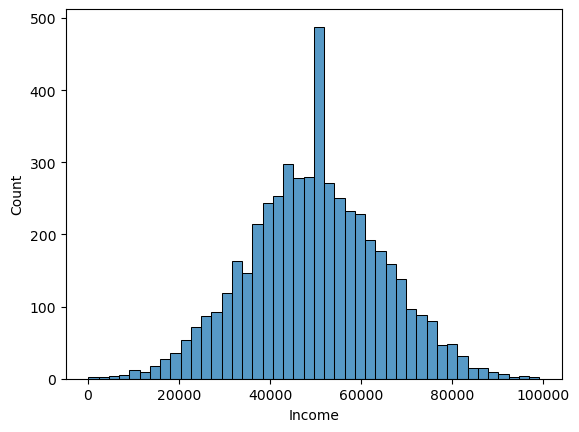

In [183]:
sns.histplot(df['Income'])

<Axes: xlabel='LoanAmount', ylabel='Count'>

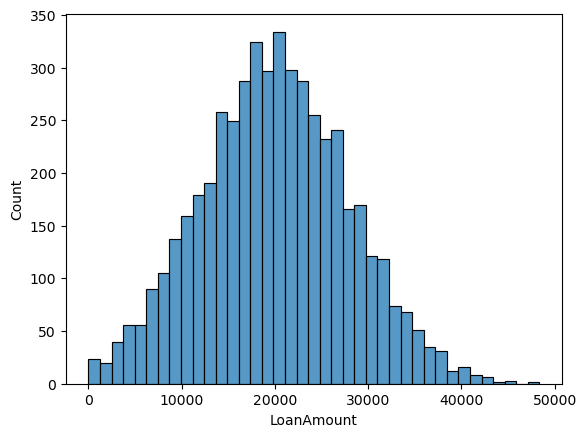

In [184]:
sns.histplot(df['LoanAmount'])

# Data Preprocessing

In [185]:
df.isna().sum()

Age                0
Income             0
LoanAmount         0
CreditScore        0
YearsExperience    0
Gender             0
Education          0
EmploymentType     0
LoanApproved       0
dtype: int64

In [186]:
df.duplicated().value_counts()

False    5000
Name: count, dtype: int64

In [187]:
df_cleaned = df.copy()

In [188]:
df_cleaned.tail()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,EmploymentType,LoanApproved
4995,24,36780.0,23383.0,575.49459,23,Male,Masters,Salaried,0
4996,66,99146.0,9760.0,306.00000,14,Male,PhD,Unemployed,0
4997,26,58100.0,18230.0,311.00000,10,Female,High School,Self-Employed,0
4998,53,58513.0,12373.0,813.00000,23,Male,PhD,Salaried,1
4999,36,58928.0,23615.0,648.00000,10,Male,Bachelors,Self-Employed,1


In [189]:
df_cleaned.rename(columns={'Gender': 'Is_Male'}, inplace=True)

In [190]:
from sklearn.preprocessing import LabelEncoder

Encoder = LabelEncoder()
df_cleaned['Is_Male'] = Encoder.fit_transform(df_cleaned['Is_Male'])

In [191]:
df_cleaned.tail()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Is_Male,Education,EmploymentType,LoanApproved
4995,24,36780.0,23383.0,575.49459,23,1,Masters,Salaried,0
4996,66,99146.0,9760.0,306.00000,14,1,PhD,Unemployed,0
4997,26,58100.0,18230.0,311.00000,10,0,High School,Self-Employed,0
4998,53,58513.0,12373.0,813.00000,23,1,PhD,Salaried,1
4999,36,58928.0,23615.0,648.00000,10,1,Bachelors,Self-Employed,1


In [192]:
df_cleaned = pd.get_dummies(df_cleaned, columns=['EmploymentType', 'Education'])

In [194]:
df_cleaned.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Is_Male,LoanApproved,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed,Education_Bachelors,Education_High School,Education_Masters,Education_PhD
0,56,48353.0,31258.0,675.0,20,0,0,False,False,True,False,True,False,False
1,69,57462.0,23262.0,586.0,6,1,0,False,True,False,False,True,False,False
2,46,44219.0,26530.0,781.0,26,1,1,False,True,False,False,False,False,True
3,32,56307.0,11531.0,549.0,11,1,0,False,False,True,True,False,False,False
4,60,37034.0,27871.0,500.0,19,0,0,False,False,True,False,True,False,False


In [196]:
df_cleaned = df_cleaned.astype(int)

In [198]:
df_cleaned.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Is_Male,LoanApproved,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed,Education_Bachelors,Education_High School,Education_Masters,Education_PhD
0,56,48353,31258,675,20,0,0,0,0,1,0,1,0,0
1,69,57462,23262,586,6,1,0,0,1,0,0,1,0,0
2,46,44219,26530,781,26,1,1,0,1,0,0,0,0,1
3,32,56307,11531,549,11,1,0,0,0,1,1,0,0,0
4,60,37034,27871,500,19,0,0,0,0,1,0,1,0,0


# Feature Scaling

In [199]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

colmns = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
df_cleaned[colmns] = scaler.fit_transform(df_cleaned[colmns])

In [221]:
df_cleaned.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Is_Male,LoanApproved,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed,Education_Bachelors,Education_High School,Education_Masters,Education_PhD
0,0.832265,-0.096053,1.432399,0.632348,0.034822,0,0,0,0,1,0,1,0,0
1,1.703719,0.521686,0.415228,0.066870,-1.180911,1,0,0,1,0,0,1,0,0
2,0.161916,-0.376405,0.830950,1.305838,0.555851,1,1,0,1,0,0,0,0,1
3,-0.776573,0.443358,-1.077074,-0.168216,-0.746721,1,0,0,0,1,1,0,0,0
4,1.100405,-0.863666,1.001539,-0.479547,-0.052016,0,0,0,0,1,0,1,0,0


In [222]:
df_cleaned.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Is_Male', 'LoanApproved', 'EmploymentType_Salaried',
       'EmploymentType_Self-Employed', 'EmploymentType_Unemployed',
       'Education_Bachelors', 'Education_High School', 'Education_Masters',
       'Education_PhD'],
      dtype='object')

In [203]:
X = df_cleaned.drop('LoanApproved', axis=1)
y = df_cleaned['LoanApproved']

In [204]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Model Training

In [210]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score 

In [211]:
model_LRG = LogisticRegression()
model_DT = DecisionTreeClassifier()
model_KNN = KNeighborsClassifier()
model_NB = GaussianNB()
model_svm = SVC()

In [212]:
models = {
    'Logistic_Regression': LogisticRegression(), 
    'Decision_Tree': DecisionTreeClassifier(), 
    'KNN': KNeighborsClassifier(),
    'Naive_Bayes': GaussianNB(),
    'SVM': SVC()
}

In [213]:
results = []

In [218]:
for name,model in  models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'name': name,
        'accuracy_score': acc, 
        'f1_score': f1,
    })

In [219]:
results

[{'name': 'Logistic_Regression',
  'accuracy_score': 0.882,
  'f1_score': 0.7216981132075472},
 {'name': 'Decision_Tree',
  'accuracy_score': 0.928,
  'f1_score': 0.8434782608695652},
 {'name': 'KNN', 'accuracy_score': 0.895, 'f1_score': 0.7563805104408353},
 {'name': 'Naive_Bayes',
  'accuracy_score': 0.886,
  'f1_score': 0.7790697674418605},
 {'name': 'SVM', 'accuracy_score': 0.936, 'f1_score': 0.8490566037735849}]

In [220]:
import joblib

joblib.dump(models['SVM'], 'model_svm.pkl')
joblib.dump(scaler, 'StandardScaler.pkl')
joblib.dump(X.columns.to_list(), 'expected_columns.pkl')

['expected_columns.pkl']

In [223]:
X_train.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Is_Male', 'EmploymentType_Salaried', 'EmploymentType_Self-Employed',
       'EmploymentType_Unemployed', 'Education_Bachelors',
       'Education_High School', 'Education_Masters', 'Education_PhD'],
      dtype='object')